### Business Impact & ROI Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("=" * 80)
print("LUNAR TECH A/B TESTING - NOTEBOOK 4: BUSINESS IMPACT & ROI")
print("=" * 80)

LUNAR TECH A/B TESTING - NOTEBOOK 4: BUSINESS IMPACT & ROI


### 1: Business Parameters

In [2]:
# A/B Test Result
control_ctr = 0.1989  # 19.89%
exp_ctr = 0.6116     # 61.16%
n_control = 10000
n_exp = 10000
control_clicks = int(n_control * control_ctr)
exp_clicks = int(n_exp * exp_ctr)


# Business Assumptions
annual_users = 10_000_000 # 10 mil users annually
enroll_rate = 0.15
arpu = 33000  # Average Revenue Per User (₹33,000 annually)
implementation_cost = 50_000  # ₹50,000 one-time cost
maintenance_cost_monthly = 10_000 


print(f"\nTEST RESULTS:")
print(f"  Control CTR: {control_ctr:.2%}")
print(f"  Experimental CTR: {exp_ctr:.2%}")
print(f"  Absolute Lift: {(exp_ctr - control_ctr)*100:.2f}pp")
print(f"  Relative Lift: {((exp_ctr - control_ctr) / control_ctr)*100:.1f}%")

print(f"\nBUSINESS ASSUMPTIONS:")
print(f"  Annual Users: {annual_users:,}")
print(f"  Enrollment Rate (from clicks): {enroll_rate:.1%}")
print(f"  ARPU (₹): ₹{arpu:,}")
print(f"  Implementation Cost: ₹{implementation_cost:,}")
print(f"  Monthly Maintenance: ₹{maintenance_cost_monthly:,}")


TEST RESULTS:
  Control CTR: 19.89%
  Experimental CTR: 61.16%
  Absolute Lift: 41.27pp
  Relative Lift: 207.5%

BUSINESS ASSUMPTIONS:
  Annual Users: 10,000,000
  Enrollment Rate (from clicks): 15.0%
  ARPU (₹): ₹33,000
  Implementation Cost: ₹50,000
  Monthly Maintenance: ₹10,000


### 2: Revenue Impact Calculation

In [3]:
# Baseline (Control) Scenario
control_annual_clicks = annual_users * control_ctr
control_annual_enrolls = control_annual_clicks * enroll_rate
control_annual_revenue = control_annual_enrolls * arpu

print(f"\nBASELINE (CONTROL) SCENARIO:")
print(f"  Annual Clicks: {control_annual_clicks:,.0f}")
print(f"  Annual Enrolls: {control_annual_enrolls:,.0f}")
print(f"  Annual Revenue: ₹{control_annual_revenue:,.0f}")

# Experimental Scenario
exp_annual_clicks = annual_users * exp_ctr
exp_annual_enrolls = exp_annual_clicks * enroll_rate
exp_annual_revenue = exp_annual_enrolls * arpu

print(f"\nEXPERIMENTAL SCENARIO (New Button):")
print(f"  Annual Clicks: {exp_annual_clicks:,.0f}")
print(f"  Annual Enrolls: {exp_annual_enrolls:,.0f}")
print(f"  Annual Revenue: ₹{exp_annual_revenue:,.0f}")

# Incremental Revenue
incremental_clicks = exp_annual_clicks - control_annual_clicks
incremental_enrolls = exp_annual_enrolls - control_annual_enrolls
incremental_revenue = exp_annual_revenue - control_annual_revenue

print(f"\nINCREMENTAL IMPACT:")
print(f"  Additional Clicks: {incremental_clicks:,.0f}")
print(f"  Additional Enrolls: {incremental_enrolls:,.0f}")
print(f"  Revenue Increase: ₹{incremental_revenue:,.0f}")


BASELINE (CONTROL) SCENARIO:
  Annual Clicks: 1,989,000
  Annual Enrolls: 298,350
  Annual Revenue: ₹9,845,550,000

EXPERIMENTAL SCENARIO (New Button):
  Annual Clicks: 6,116,000
  Annual Enrolls: 917,400
  Annual Revenue: ₹30,274,200,000

INCREMENTAL IMPACT:
  Additional Clicks: 4,127,000
  Additional Enrolls: 619,050
  Revenue Increase: ₹20,428,650,000


### 3: ROI & Payback Analysis

In [4]:
# Year 1 costs
year1_maintenance = maintenance_cost_monthly * 12
year1_total_cost = implementation_cost + year1_maintenance

# Year 1 net benefit
year1_net = incremental_revenue - year1_total_cost
year1_roi = (year1_net / year1_total_cost) * 100

# Payback period
daily_incremental = incremental_revenue / 365
daily_maintenance = maintenance_cost_monthly / 30
daily_net = daily_incremental - daily_maintenance
payback_days = implementation_cost / daily_net

print(f"\nYEAR 1 FINANCIAL SUMMARY:")
print(f"  Implementation Cost: ₹{implementation_cost:,}")
print(f"  Annual Maintenance: ₹{year1_maintenance:,}")
print(f"  Total Year 1 Cost: ₹{year1_total_cost:,}")

print(f"\n  Incremental Revenue: ₹{incremental_revenue:,.0f}")
print(f"  Year 1 Net Benefit: ₹{year1_net:,.0f}")
print(f"  Year 1 ROI: {year1_roi:,.0f}%")
print(f"  ROI Multiplier: {year1_roi/100:.1f}x")

print(f"\n  Payback Period: {payback_days:.1f} days ({payback_days/7:.1f} weeks)")

# Multi-year projection
print(f"\nMULTI-YEAR PROJECTION:")
for year in range(1, 6):
    annual_maintenance = maintenance_cost_monthly * 12
    net_revenue = (incremental_revenue * year) - (annual_maintenance * year) - implementation_cost
    cumulative_roi = (net_revenue / implementation_cost) * 100
    print(f"  Year {year}: ₹{net_revenue:,.0f} (Cumulative ROI: {cumulative_roi:,.0f}%)")


YEAR 1 FINANCIAL SUMMARY:
  Implementation Cost: ₹50,000
  Annual Maintenance: ₹120,000
  Total Year 1 Cost: ₹170,000

  Incremental Revenue: ₹20,428,650,000
  Year 1 Net Benefit: ₹20,428,480,000
  Year 1 ROI: 12,016,753%
  ROI Multiplier: 120167.5x

  Payback Period: 0.0 days (0.0 weeks)

MULTI-YEAR PROJECTION:
  Year 1: ₹20,428,480,000 (Cumulative ROI: 40,856,960%)
  Year 2: ₹40,857,010,000 (Cumulative ROI: 81,714,020%)
  Year 3: ₹61,285,540,000 (Cumulative ROI: 122,571,080%)
  Year 4: ₹81,714,070,000 (Cumulative ROI: 163,428,140%)
  Year 5: ₹102,142,600,000 (Cumulative ROI: 204,285,200%)


### 4: Sensitivity Analysis

In [5]:
# Scenario 1: Lower user volume
users_low = 5_000_000
revenue_low = (users_low * (exp_ctr - control_ctr) * enroll_rate * arpu) - year1_total_cost
roi_low = (revenue_low / year1_total_cost) * 100

# Scenario 2: Higher user volume
users_high = 15_000_000
revenue_high = (users_high * (exp_ctr - control_ctr) * enroll_rate * arpu) - year1_total_cost
roi_high = (revenue_high / year1_total_cost) * 100

# Scenario 3: Lower ARPU
arpu_low = 20000
revenue_arpu_low = (annual_users * (exp_ctr - control_ctr) * enroll_rate * arpu_low) - year1_total_cost
roi_arpu_low = (revenue_arpu_low / year1_total_cost) * 100

# Scenario 4: Higher ARPU
arpu_high = 50000
revenue_arpu_high = (annual_users * (exp_ctr - control_ctr) * enroll_rate * arpu_high) - year1_total_cost
roi_arpu_high = (revenue_arpu_high / year1_total_cost) * 100

# Scenario 5: Lower enrollment rate
enroll_low = 0.08
revenue_enroll_low = (annual_users * (exp_ctr - control_ctr) * enroll_low * arpu) - year1_total_cost
roi_enroll_low = (revenue_enroll_low / year1_total_cost) * 100

# Scenario 6: Higher enrollment rate
enroll_high = 0.25
revenue_enroll_high = (annual_users * (exp_ctr - control_ctr) * enroll_high * arpu) - year1_total_cost
roi_enroll_high = (revenue_enroll_high / year1_total_cost) * 100

print(f"\nBASE CASE:")
print(f"  Net Year 1 Benefit: ₹{year1_net:,.0f}")
print(f"  ROI: {year1_roi:,.0f}%")

print(f"\nSCENARIO 1: Lower User Volume (5M vs 10M):")
print(f"  Net Year 1 Benefit: ₹{revenue_low:,.0f}")
print(f"  ROI: {roi_low:,.0f}%")

print(f"\nSCENARIO 2: Higher User Volume (15M vs 10M):")
print(f"  Net Year 1 Benefit: ₹{revenue_high:,.0f}")
print(f"  ROI: {roi_high:,.0f}%")

print(f"\nSCENARIO 3: Lower ARPU (₹20k vs ₹33k):")
print(f"  Net Year 1 Benefit: ₹{revenue_arpu_low:,.0f}")
print(f"  ROI: {roi_arpu_low:,.0f}%")

print(f"\nSCENARIO 4: Higher ARPU (₹50k vs ₹33k):")
print(f"  Net Year 1 Benefit: ₹{revenue_arpu_high:,.0f}")
print(f"  ROI: {roi_arpu_high:,.0f}%")

print(f"\nSCENARIO 5: Lower Enrollment (8% vs 15%):")
print(f"  Net Year 1 Benefit: ₹{revenue_enroll_low:,.0f}")
print(f"  ROI: {roi_enroll_low:,.0f}%")

print(f"\nSCENARIO 6: Higher Enrollment (25% vs 15%):")
print(f"  Net Year 1 Benefit: ₹{revenue_enroll_high:,.0f}")
print(f"  ROI: {roi_enroll_high:,.0f}%")


BASE CASE:
  Net Year 1 Benefit: ₹20,428,480,000
  ROI: 12,016,753%

SCENARIO 1: Lower User Volume (5M vs 10M):
  Net Year 1 Benefit: ₹10,214,155,000
  ROI: 6,008,326%

SCENARIO 2: Higher User Volume (15M vs 10M):
  Net Year 1 Benefit: ₹30,642,805,000
  ROI: 18,025,179%

SCENARIO 3: Lower ARPU (₹20k vs ₹33k):
  Net Year 1 Benefit: ₹12,380,830,000
  ROI: 7,282,841%

SCENARIO 4: Higher ARPU (₹50k vs ₹33k):
  Net Year 1 Benefit: ₹30,952,330,000
  ROI: 18,207,253%

SCENARIO 5: Lower Enrollment (8% vs 15%):
  Net Year 1 Benefit: ₹10,895,110,000
  ROI: 6,408,888%

SCENARIO 6: Higher Enrollment (25% vs 15%):
  Net Year 1 Benefit: ₹34,047,580,000
  ROI: 20,027,988%


### 5: Visualizations

✓ Saved: lunar_financial_analysis.png


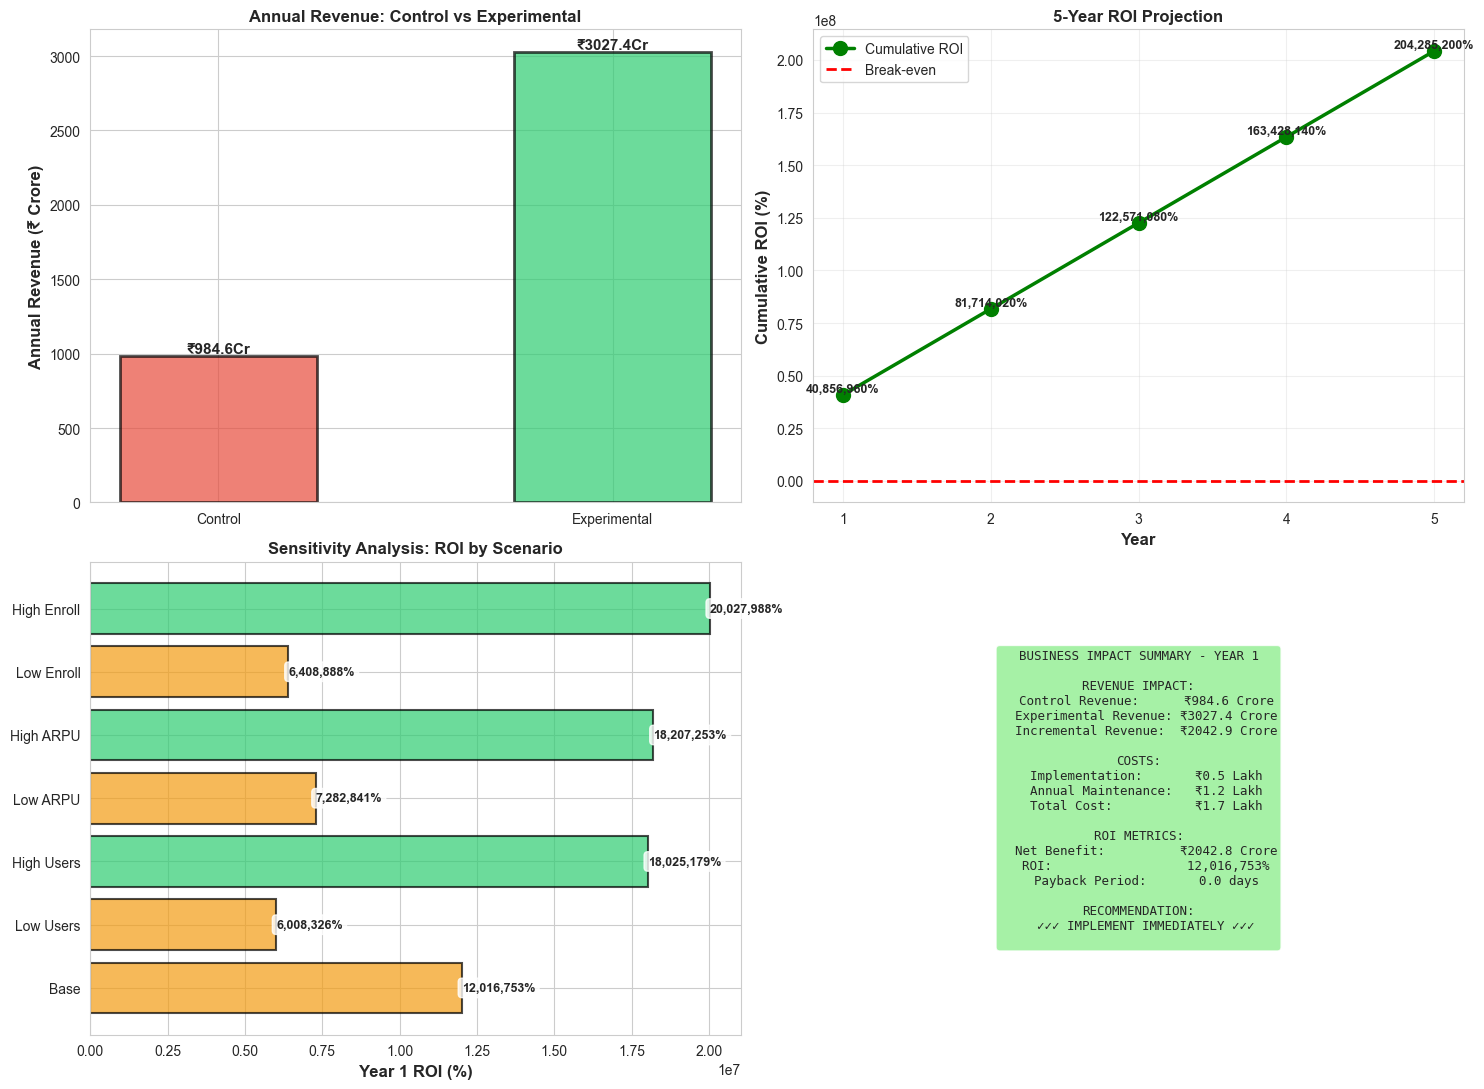

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Plot 1: Revenue Comparison
ax1 = axes[0, 0]
scenarios = ['Control', 'Experimental']
revenues = [control_annual_revenue / 10_000_000, exp_annual_revenue / 10_000_000]
colors = ['#e74c3c', '#2ecc71']
bars = ax1.bar(scenarios, revenues, color=colors, alpha=0.7, edgecolor='black', linewidth=2, width=0.5)
ax1.set_ylabel('Annual Revenue (₹ Crore)', fontsize=12, fontweight='bold')
ax1.set_title('Annual Revenue: Control vs Experimental', fontsize=12, fontweight='bold')
for bar, value in zip(bars, revenues):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'₹{value:.1f}Cr', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 2: Multi-year ROI Projection
ax2 = axes[0, 1]
years = np.arange(1, 6)
cumulative_roi_values = []
for year in years:
    net = (incremental_revenue * year) - (maintenance_cost_monthly * 12 * year) - implementation_cost
    roi = (net / implementation_cost) * 100
    cumulative_roi_values.append(roi)

ax2.plot(years, cumulative_roi_values, 'go-', linewidth=2.5, markersize=10, label='Cumulative ROI')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Break-even')
ax2.set_xlabel('Year', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative ROI (%)', fontsize=12, fontweight='bold')
ax2.set_title('5-Year ROI Projection', fontsize=12, fontweight='bold')
ax2.set_xticks(years)
ax2.legend()
ax2.grid(alpha=0.3)
for x, y in zip(years, cumulative_roi_values):
    ax2.text(x, y, f'{y:,.0f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Plot 3: Sensitivity Analysis Heatmap
ax3 = axes[1, 0]
scenarios_names = ['Base', 'Low Users', 'High Users', 'Low ARPU', 'High ARPU', 'Low Enroll', 'High Enroll']
roi_values = [year1_roi, roi_low, roi_high, roi_arpu_low, roi_arpu_high, roi_enroll_low, roi_enroll_high]
colors_sens = ['#2ecc71' if r > year1_roi else '#f39c12' for r in roi_values]
bars = ax3.barh(scenarios_names, roi_values, color=colors_sens, alpha=0.7, edgecolor='black', linewidth=1.5)
ax3.set_xlabel('Year 1 ROI (%)', fontsize=12, fontweight='bold')
ax3.set_title('Sensitivity Analysis: ROI by Scenario', fontsize=12, fontweight='bold')
for i, (bar, value) in enumerate(zip(bars, roi_values)):
    ax3.text(value, bar.get_y() + bar.get_height()/2.,
             f'{value:,.0f}%', ha='left', va='center', fontweight='bold', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot 4: Business Summary
ax4 = axes[1, 1]
ax4.axis('off')
summary = f"""BUSINESS IMPACT SUMMARY - YEAR 1

REVENUE IMPACT:
  Control Revenue:      ₹{control_annual_revenue/10_000_000:.1f} Crore
  Experimental Revenue: ₹{exp_annual_revenue/10_000_000:.1f} Crore
  Incremental Revenue:  ₹{incremental_revenue/10_000_000:.1f} Crore

COSTS:
  Implementation:       ₹{implementation_cost/100_000:.1f} Lakh
  Annual Maintenance:   ₹{year1_maintenance/100_000:.1f} Lakh
  Total Cost:           ₹{year1_total_cost/100_000:.1f} Lakh

ROI METRICS:
  Net Benefit:          ₹{year1_net/10_000_000:.1f} Crore
  ROI:                  {year1_roi:,.0f}%
  Payback Period:       {payback_days:.1f} days

RECOMMENDATION:
  ✓✓✓ IMPLEMENT IMMEDIATELY ✓✓✓
"""
ax4.text(0.5, 0.5, summary, transform=ax4.transAxes,
         fontsize=9, verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8), family='monospace')

plt.tight_layout()
plt.savefig('lunar_financial_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: lunar_financial_analysis.png")
plt.show()

### 6: Save Business Metrics

In [7]:
# Business metrics
business_metrics = {
    'Metric': [
        'Control Annual Revenue',
        'Experimental Annual Revenue',
        'Incremental Revenue',
        'Implementation Cost',
        'Annual Maintenance Cost',
        'Year 1 Net Benefit',
        'Year 1 ROI (%)',
        'Payback Period (Days)',
        'Annual Additional Enrolls',
        'Annual Additional Clicks'
    ],
    'Value': [
        f'{control_annual_revenue:,.0f}',
        f'{exp_annual_revenue:,.0f}',
        f'{incremental_revenue:,.0f}',
        f'{implementation_cost:,}',
        f'{year1_maintenance:,}',
        f'{year1_net:,.0f}',
        f'{year1_roi:,.2f}',
        f'{payback_days:.1f}',
        f'{incremental_enrolls:,.0f}',
        f'{incremental_clicks:,.0f}'
    ]
}

metrics_df = pd.DataFrame(business_metrics)
metrics_df.to_csv('lunar_business_metrics.csv', index=False)
print("✓ Saved: lunar_business_metrics.csv")

# Sensitivity analysis
sensitivity_data = {
    'Scenario': ['Base Case', 'Low Users (5M)', 'High Users (15M)', 'Low ARPU (₹20k)', 'High ARPU (₹50k)', 'Low Enroll (8%)', 'High Enroll (25%)'],
    'Year1 ROI (%)': [year1_roi, roi_low, roi_high, roi_arpu_low, roi_arpu_high, roi_enroll_low, roi_enroll_high],
    'Net Benefit': [year1_net, revenue_low, revenue_high, revenue_arpu_low, revenue_arpu_high, revenue_enroll_low, revenue_enroll_high]
}

sensitivity_df = pd.DataFrame(sensitivity_data)
sensitivity_df.to_csv('lunar_sensitivity_analysis.csv', index=False)
print("✓ Saved: lunar_sensitivity_analysis.csv")

print("\n✓ NOTEBOOK 4 COMPLETE - BUSINESS IMPACT ANALYSIS FINISHED")

✓ Saved: lunar_business_metrics.csv
✓ Saved: lunar_sensitivity_analysis.csv

✓ NOTEBOOK 4 COMPLETE - BUSINESS IMPACT ANALYSIS FINISHED
